# Survival Analysis: ML vs Statistical Models Comparison

This notebook compares Machine Learning and Statistical models for survival analysis problems.

## Problem Type: Survival Analysis
## Datasets:
- Customer Churn
- Patient Survival

## Models:
**ML Models:**
- Random Forest

**Statistical Models:**
- Cox Regression (lifelines)
- Kaplan-Meier (lifelines)


In [1]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time
import psutil
import os

# ML Models
from sklearn.ensemble import RandomForestRegressor

# Statistical Models (Survival Analysis)
from lifelines import CoxPHFitter, KaplanMeierFitter

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## Utility Functions

Functions for survival analysis dataset loading, model evaluation, and comparison.


In [2]:
def load_dataset(dataset_name):
    """Load and preprocess survival analysis datasets."""
    np.random.seed(42)
    
    if dataset_name == 'customer_churn':
        # Generate synthetic customer churn data
        n_samples = 1000
        n_features = 8
        
        # Generate features
        X = np.random.randn(n_samples, n_features)
        
        # Generate survival times (exponential distribution with hazard dependent on features)
        hazard = np.exp(-(X[:, 0] * 0.5 + X[:, 1] * 0.3 + np.random.randn(n_samples) * 0.2))
        survival_times = np.random.exponential(scale=1/hazard)
        survival_times = np.clip(survival_times, 0, 100)  # Cap at 100
        
        # Generate event indicators (some right-censoring)
        event_indicators = np.random.binomial(1, 0.8, n_samples)
        
        feature_names = [f'feature_{i+1}' for i in range(n_features)]
        
    elif dataset_name == 'patient_survival':
        # Generate synthetic patient survival data
        n_samples = 1000
        n_features = 6
        
        # Generate features (age, treatment, etc.)
        X = np.random.randn(n_samples, n_features)
        X[:, 0] = np.abs(X[:, 0]) * 30 + 40  # Age (40-70)
        
        # Generate survival times (Weibull distribution)
        scale = 50 + X[:, 0] * 0.5 + X[:, 1] * 2
        survival_times = np.random.weibull(a=2, size=n_samples) * scale
        survival_times = np.clip(survival_times, 0, 200)  # Cap at 200
        
        # Generate event indicators
        event_indicators = np.random.binomial(1, 0.75, n_samples)
        
        feature_names = [f'feature_{i+1}' for i in range(n_features)]
        
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")
    
    # Create DataFrame for lifelines
    df = pd.DataFrame(X, columns=feature_names)
    df['duration'] = survival_times
    df['event'] = event_indicators
    
    return X, survival_times, event_indicators, df, feature_names


def get_memory_usage():
    """Get current memory usage in MB."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024 / 1024


def evaluate_random_forest(X_train, X_test, durations_train, durations_test, 
                          events_train, events_test):
    """Evaluate Random Forest for survival analysis."""
    start_time = time.time()
    memory_before = get_memory_usage()
    
    # Train Random Forest to predict survival times
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, durations_train)
    
    training_time = time.time() - start_time
    
    pred_start = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - pred_start
    
    memory_after = get_memory_usage()
    memory_usage = memory_after - memory_before
    
    # Calculate metrics
    r2 = r2_score(durations_test, y_pred)
    rmse = np.sqrt(mean_squared_error(durations_test, y_pred))
    mae = mean_absolute_error(durations_test, y_pred)
    
    results = {
        'model_name': 'Random Forest',
        'model_category': 'ml',
        'test_r2': r2,
        'test_rmse': rmse,
        'test_mae': mae,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'memory_usage': memory_usage,
        'explainability_score': 50,
        'y_test_pred': y_pred,
        'y_test': durations_test
    }
    
    return results


def evaluate_cox_regression(df_train, df_test, durations_test):
    """Evaluate Cox Regression model."""
    start_time = time.time()
    memory_before = get_memory_usage()
    
    # Fit Cox model
    cph = CoxPHFitter()
    cph.fit(df_train, duration_col='duration', event_col='event')
    
    training_time = time.time() - start_time
    
    pred_start = time.time()
    # Predict partial hazards
    partial_hazards = cph.predict_partial_hazard(df_test)
    # Convert to predicted survival times (simplified)
    y_pred = -np.log(partial_hazards) * np.mean(durations_test)
    prediction_time = time.time() - pred_start
    
    memory_after = get_memory_usage()
    memory_usage = memory_after - memory_before
    
    # Calculate metrics
    r2 = r2_score(durations_test, y_pred)
    rmse = np.sqrt(mean_squared_error(durations_test, y_pred))
    mae = mean_absolute_error(durations_test, y_pred)
    
    results = {
        'model_name': 'Cox Regression (lifelines)',
        'model_category': 'statistical',
        'test_r2': r2,
        'test_rmse': rmse,
        'test_mae': mae,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'memory_usage': memory_usage,
        'explainability_score': 70,
        'y_test_pred': y_pred,
        'y_test': durations_test,
        'model': cph
    }
    
    return results


def evaluate_kaplan_meier(df_train, df_test, durations_test):
    """Evaluate Kaplan-Meier estimator."""
    start_time = time.time()
    memory_before = get_memory_usage()
    
    # Fit Kaplan-Meier
    kmf = KaplanMeierFitter()
    kmf.fit(df_train['duration'], df_train['event'])
    
    training_time = time.time() - start_time
    
    pred_start = time.time()
    # Kaplan-Meier doesn't predict individual survival times
    # Use median survival time as prediction
    median_survival = kmf.median_survival_time_
    if pd.isna(median_survival):
        median_survival = np.median(df_train['duration'])
    y_pred = np.full(len(durations_test), median_survival)
    prediction_time = time.time() - pred_start
    
    memory_after = get_memory_usage()
    memory_usage = memory_after - memory_before
    
    # Calculate metrics
    r2 = r2_score(durations_test, y_pred)
    rmse = np.sqrt(mean_squared_error(durations_test, y_pred))
    mae = mean_absolute_error(durations_test, y_pred)
    
    results = {
        'model_name': 'Kaplan-Meier (lifelines)',
        'model_category': 'statistical',
        'test_r2': r2,
        'test_rmse': rmse,
        'test_mae': mae,
        'training_time': training_time,
        'prediction_time': prediction_time,
        'memory_usage': memory_usage,
        'explainability_score': 70,
        'y_test_pred': y_pred,
        'y_test': durations_test,
        'model': kmf
    }
    
    return results


print("✅ Utility functions defined!")


✅ Utility functions defined!


## Main Comparison Function


In [4]:
def run_survival_analysis_comparison(dataset_name, test_size=0.2, random_state=42):
    """Run comprehensive comparison for a survival analysis dataset."""
    
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name.upper()}")
    print(f"{'='*60}\n")
    
    # Load dataset
    X, durations, events, df, feature_names = load_dataset(dataset_name)
    print(f"Dataset shape: {X.shape}")
    print(f"Features: {len(feature_names)}")
    print(f"Samples: {len(durations)}")
    print(f"Events: {np.sum(events)} ({100*np.sum(events)/len(events):.1f}%)")
    print(f"Censored: {len(events) - np.sum(events)} ({100*(len(events)-np.sum(events))/len(events):.1f}%)")
    
    # Split data
    X_train, X_test, durations_train, durations_test, events_train, events_test = train_test_split(
        X, durations, events, test_size=test_size, random_state=random_state
    )
    
    # Create DataFrames for lifelines
    df_train = pd.DataFrame(X_train, columns=feature_names)
    df_train['duration'] = durations_train
    df_train['event'] = events_train
    
    df_test = pd.DataFrame(X_test, columns=feature_names)
    df_test['duration'] = durations_test
    df_test['event'] = events_test
    
    all_results = []
    
    # ML Models
    print("\n📊 Training ML Models...")
    print("  - Random Forest...")
    rf_results = evaluate_random_forest(X_train, X_test, durations_train, durations_test,
                                       events_train, events_test)
    all_results.append(rf_results)
    
    # Statistical Models
    print("\n📈 Training Statistical Models...")
    print("  - Cox Regression...")
    try:
        cox_results = evaluate_cox_regression(df_train, df_test, durations_test)
        all_results.append(cox_results)
    except Exception as e:
        print(f"    Warning: Cox Regression failed: {e}")
    
    print("  - Kaplan-Meier...")
    try:
        km_results = evaluate_kaplan_meier(df_train, df_test, durations_test)
        all_results.append(km_results)
    except Exception as e:
        print(f"    Warning: Kaplan-Meier failed: {e}")
    
    # Create results DataFrame
    results_df = pd.DataFrame([
        {
            'model_name': r['model_name'],
            'model_category': r['model_category'],
            'test_r2': r['test_r2'],
            'test_rmse': r['test_rmse'],
            'test_mae': r['test_mae'],
            'training_time': r['training_time'],
            'prediction_time': r['prediction_time'],
            'memory_usage': r['memory_usage'],
            'explainability_score': r['explainability_score']
        }
        for r in all_results
    ])
    
    return results_df, all_results, X_test, durations_test, events_test, df


print("✅ Comparison function defined!")


✅ Comparison function defined!


In [5]:
# Define datasets
survival_datasets = ['customer_churn', 'patient_survival']

# Store all results
all_dataset_results = {}

for dataset in survival_datasets:
    try:
        results_df, detailed_results, X_test, durations_test, events_test, df = run_survival_analysis_comparison(dataset)
        all_dataset_results[dataset] = {
            'results_df': results_df,
            'detailed_results': detailed_results,
            'X_test': X_test,
            'durations_test': durations_test,
            'events_test': events_test,
            'df': df
        }
        print(f"\n✅ Completed: {dataset}")
        print(results_df[['model_name', 'model_category', 'test_r2', 'test_rmse', 'training_time']])
        print("\n" + "-"*60 + "\n")
    except Exception as e:
        print(f"❌ Error with {dataset}: {e}")
        import traceback
        traceback.print_exc()
        continue

print("✅ All comparisons completed!")



Dataset: CUSTOMER_CHURN

Dataset shape: (1000, 8)
Features: 8
Samples: 1000
Events: 803 (80.3%)
Censored: 197 (19.7%)

📊 Training ML Models...
  - Random Forest...

📈 Training Statistical Models...
  - Cox Regression...
  - Kaplan-Meier...

✅ Completed: customer_churn
                   model_name model_category   test_r2  test_rmse  \
0               Random Forest             ml  0.095361   2.442352   
1  Cox Regression (lifelines)    statistical -0.142263   2.744440   
2    Kaplan-Meier (lifelines)    statistical -0.049843   2.631073   

   training_time  
0       0.392228  
1       0.049940  
2       0.005255  

------------------------------------------------------------


Dataset: PATIENT_SURVIVAL

Dataset shape: (1000, 6)
Features: 6
Samples: 1000
Events: 779 (77.9%)
Censored: 221 (22.1%)

📊 Training ML Models...
  - Random Forest...

📈 Training Statistical Models...
  - Cox Regression...
  - Kaplan-Meier...

✅ Completed: patient_survival
                   model_name model_cate

## Visualizations

Create visualizations to compare model performance and survival curves.


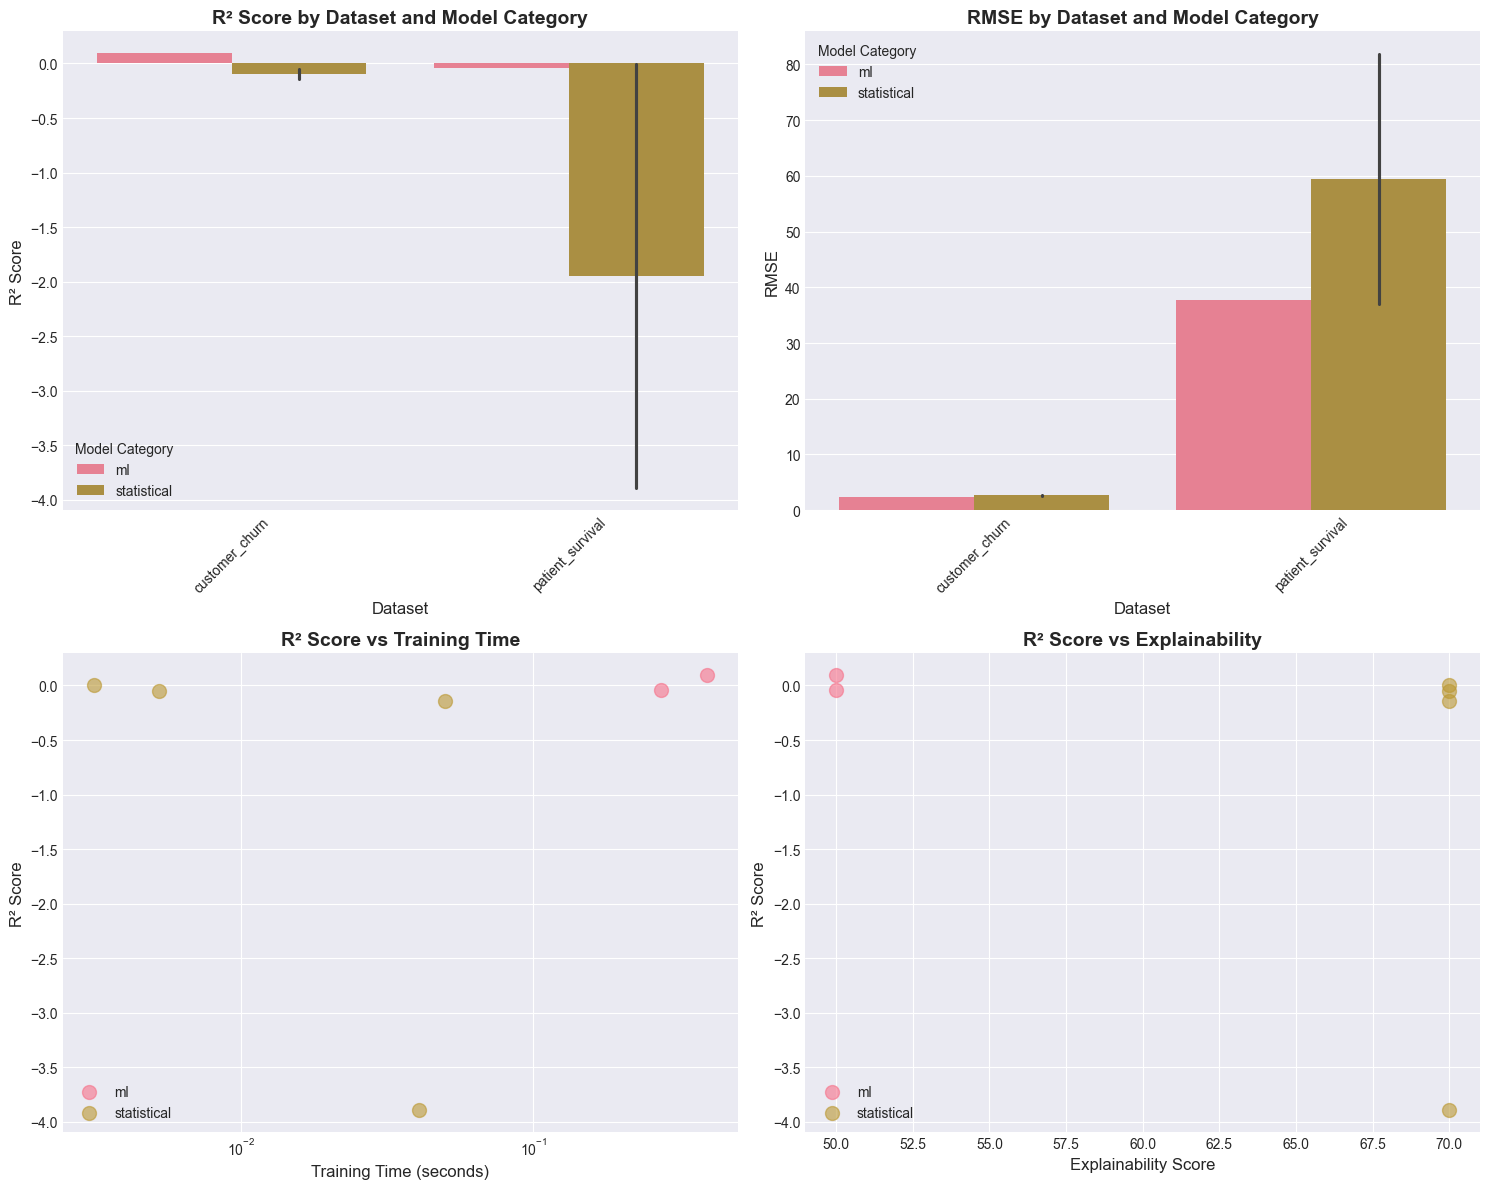

✅ Visualizations created!


In [6]:
# Combine all results for visualization
all_results_combined = []
for dataset_name, data in all_dataset_results.items():
    df = data['results_df'].copy()
    df['dataset'] = dataset_name
    all_results_combined.append(df)

if len(all_results_combined) > 0:
    combined_df = pd.concat(all_results_combined, ignore_index=True)
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. R² comparison
    ax1 = axes[0, 0]
    sns.barplot(data=combined_df, x='dataset', y='test_r2', hue='model_category', ax=ax1)
    ax1.set_title('R² Score by Dataset and Model Category', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Dataset', fontsize=12)
    ax1.set_ylabel('R² Score', fontsize=12)
    ax1.legend(title='Model Category')
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. RMSE comparison
    ax2 = axes[0, 1]
    sns.barplot(data=combined_df, x='dataset', y='test_rmse', hue='model_category', ax=ax2)
    ax2.set_title('RMSE by Dataset and Model Category', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Dataset', fontsize=12)
    ax2.set_ylabel('RMSE', fontsize=12)
    ax2.legend(title='Model Category')
    ax2.tick_params(axis='x', rotation=45)
    
    # 3. R² vs Training Time
    ax3 = axes[1, 0]
    for category in combined_df['model_category'].unique():
        data = combined_df[combined_df['model_category'] == category]
        ax3.scatter(data['training_time'], data['test_r2'], 
                   label=category, alpha=0.6, s=100)
    ax3.set_xlabel('Training Time (seconds)', fontsize=12)
    ax3.set_ylabel('R² Score', fontsize=12)
    ax3.set_title('R² Score vs Training Time', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.set_xscale('log')
    
    # 4. Explainability vs R²
    ax4 = axes[1, 1]
    for category in combined_df['model_category'].unique():
        data = combined_df[combined_df['model_category'] == category]
        ax4.scatter(data['explainability_score'], data['test_r2'], 
                   label=category, alpha=0.6, s=100)
    ax4.set_xlabel('Explainability Score', fontsize=12)
    ax4.set_ylabel('R² Score', fontsize=12)
    ax4.set_title('R² Score vs Explainability', fontsize=14, fontweight='bold')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualizations created!")
else:
    print("⚠️ No results to visualize")


## Survival Curves Visualization

Visualize survival curves for statistical models.


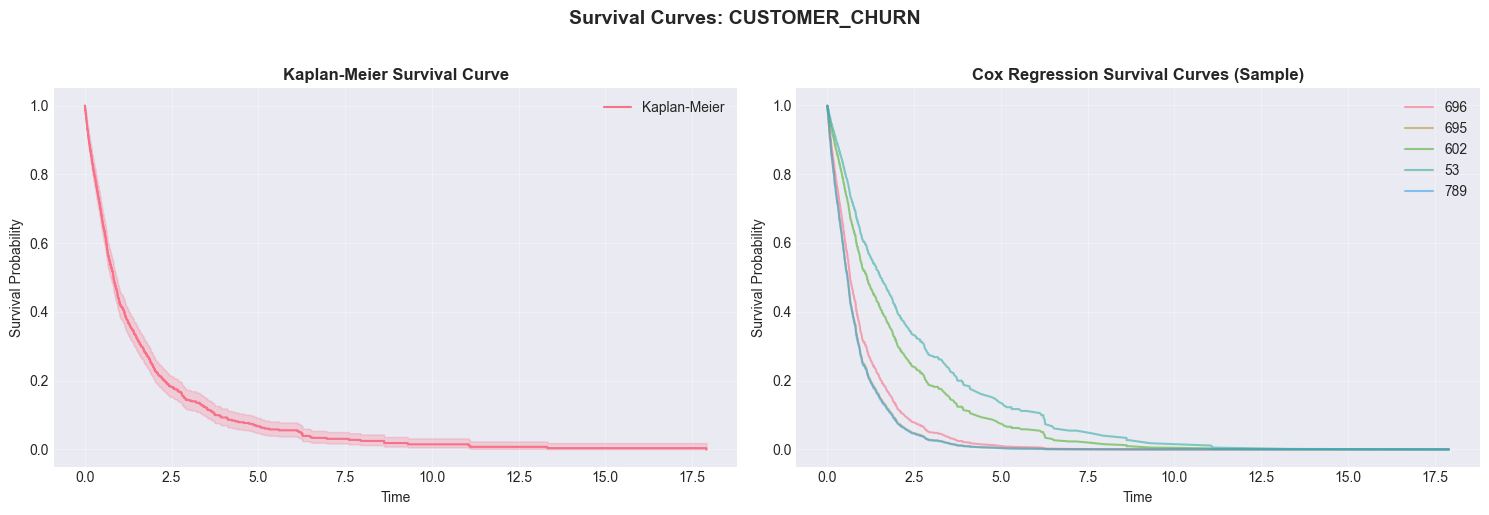

✅ Survival curve visualizations created!


In [7]:
# Plot survival curves for statistical models
if len(all_dataset_results) > 0:
    first_dataset = list(all_dataset_results.keys())[0]
    data = all_dataset_results[first_dataset]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot Kaplan-Meier survival curve
    ax1 = axes[0]
    for result in data['detailed_results']:
        if result['model_name'] == 'Kaplan-Meier (lifelines)' and 'model' in result:
            kmf = result['model']
            kmf.plot_survival_function(ax=ax1, label='Kaplan-Meier')
            ax1.set_title('Kaplan-Meier Survival Curve', fontsize=12, fontweight='bold')
            ax1.set_xlabel('Time', fontsize=10)
            ax1.set_ylabel('Survival Probability', fontsize=10)
            ax1.legend()
            ax1.grid(True, alpha=0.3)
    
    # Plot Cox Regression survival curves (if available)
    ax2 = axes[1]
    for result in data['detailed_results']:
        if result['model_name'] == 'Cox Regression (lifelines)' and 'model' in result:
            cph = result['model']
            # Plot survival curves for a few sample individuals
            sample_indices = np.random.choice(len(data['df']), size=min(5, len(data['df'])), replace=False)
            for idx in sample_indices:
                sample_df = data['df'].iloc[[idx]]
                cph.predict_survival_function(sample_df).plot(ax=ax2, alpha=0.6)
            ax2.set_title('Cox Regression Survival Curves (Sample)', fontsize=12, fontweight='bold')
            ax2.set_xlabel('Time', fontsize=10)
            ax2.set_ylabel('Survival Probability', fontsize=10)
            ax2.grid(True, alpha=0.3)
    
    plt.suptitle(f'Survival Curves: {first_dataset.upper()}', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("✅ Survival curve visualizations created!")


## Summary Statistics

Display summary statistics across all datasets.


In [8]:
# Summary statistics
if len(all_results_combined) > 0:
    print("="*80)
    print("SURVIVAL ANALYSIS MODELS COMPARISON SUMMARY")
    print("="*80)
    
    print("\n📊 Overall Performance by Model Category:")
    summary = combined_df.groupby('model_category').agg({
        'test_r2': ['mean', 'std', 'min', 'max'],
        'test_rmse': ['mean', 'std'],
        'training_time': ['mean', 'std'],
        'explainability_score': 'mean'
    }).round(4)
    print(summary)
    
    print("\n🏆 Best Model per Dataset:")
    for dataset in survival_datasets:
        if dataset in all_dataset_results:
            df = all_dataset_results[dataset]['results_df']
            if len(df) > 0:
                best_model = df.loc[df['test_r2'].idxmax()]
                print(f"\n{dataset.upper()}:")
                print(f"  Model: {best_model['model_name']}")
                print(f"  Category: {best_model['model_category']}")
                print(f"  R²: {best_model['test_r2']:.4f}")
                print(f"  RMSE: {best_model['test_rmse']:.4f}")
                print(f"  Training Time: {best_model['training_time']:.4f}s")
    
    print("\n⚡ Fastest Model:")
    fastest = combined_df.loc[combined_df['training_time'].idxmin()]
    print(f"  Model: {fastest['model_name']}")
    print(f"  Dataset: {fastest['dataset']}")
    print(f"  Training Time: {fastest['training_time']:.4f}s")
    
    print("\n🧠 Most Interpretable Model:")
    most_interp = combined_df.loc[combined_df['explainability_score'].idxmax()]
    print(f"  Model: {most_interp['model_name']}")
    print(f"  Dataset: {most_interp['dataset']}")
    print(f"  Explainability Score: {most_interp['explainability_score']}/100")
    
    print("\n" + "="*80)
else:
    print("⚠️ No results available for summary")


SURVIVAL ANALYSIS MODELS COMPARISON SUMMARY

📊 Overall Performance by Model Category:
               test_r2                         test_rmse           \
                  mean     std     min     max      mean      std   
model_category                                                      
ml              0.0271  0.0965 -0.0411  0.0954   20.0853  24.9509   
statistical    -1.0224  1.9177 -3.8976 -0.0001   31.0459  37.5173   

               training_time         explainability_score  
                        mean     std                 mean  
model_category                                             
ml                    0.3323  0.0848                 50.0  
statistical           0.0247  0.0240                 70.0  

🏆 Best Model per Dataset:

CUSTOMER_CHURN:
  Model: Random Forest
  Category: ml
  R²: 0.0954
  RMSE: 2.4424
  Training Time: 0.3922s

PATIENT_SURVIVAL:
  Model: Kaplan-Meier (lifelines)
  Category: statistical
  R²: -0.0001
  RMSE: 36.9774
  Training Time: 0.0031s

